# <span style="color:darkred"> **Assignment 4**  </span>

<font size = "5">

In [1]:
# import library
import pandas as pd
import matplotlib.pyplot as plt
import re


# <span style="color:darkblue"> **Step1: Descriptives and Bill Identifiers**  </span>

<font size = "4">

First, I read the raw dataset and performed basic descriptive checks to understand data structure and quality. This included examining the number of observations and variables, variable types, and the missing values. 

To verify whether **bill_number** can be a unique identifier, I examined its frequency using value_counts(). And I found that some bill numbers appeared multiple times in the dataset. I inspected the data, found that some of these were true duplicates, but some of the duplicates can be solved by combing **bill_number** and **bill_type**.

In [2]:
# Read data
bills_actions = pd.read_csv("data_raw/bills_actions.csv")

# Descriptives
# Check the sample size and numbers of variables
print(bills_actions.shape)

# The value types of variables 
print(bills_actions.dtypes)

# If the dataset has missing values
print(bills_actions.isna().sum())


(3303, 7)
Congress        int64
bill_number     int64
bill_type      object
action         object
main_action    object
category       object
member_id       int64
dtype: object
Congress       0
bill_number    0
bill_type      0
action         0
main_action    0
category       0
member_id      0
dtype: int64


In [3]:
# EXISTING bill identifier: bill_number
bills_actions["bill_number"].value_counts()

bill_number
2740    243
3055    187
2500     96
1        75
1585     46
       ... 
127       1
125       1
19        1
16        1
695       1
Name: count, Length: 1331, dtype: int64

In [4]:
# Create NEW bill identifier = bill_number + bill_type
bill_id = (bills_actions["bill_type"] + bills_actions["bill_number"].astype(str))

# Write bill_id in a column in the dataset
bills_actions["bill_id"] = (bills_actions["bill_type"] + bills_actions["bill_number"].astype(str))

# Count distinct bills
bills_actions["bill_id"].nunique()


1494

<font size = "4">

**Interpretation of Descriptives and Bill Identifier**

The dataset contains 3,303 observations and 7 variables, with no missing values across all variables.

Creating the combined bill_id resolved ambiguities and produced 1,494 unique bill ids, which will be used for subsequent analyses.

# <span style="color:darkblue"> **Step2: Calculate Categories Proportions** </span>

<font size = "4">

In this section, I calculated the proportion of observations in each bill category and display the proportions in a pie chart. 

I then use cross tabulation between category and main_action, with normalize="index" to compute proportions within each category. I visualized the results using a stacked bar chart, making it easy to compare the composition of main actions across categories.

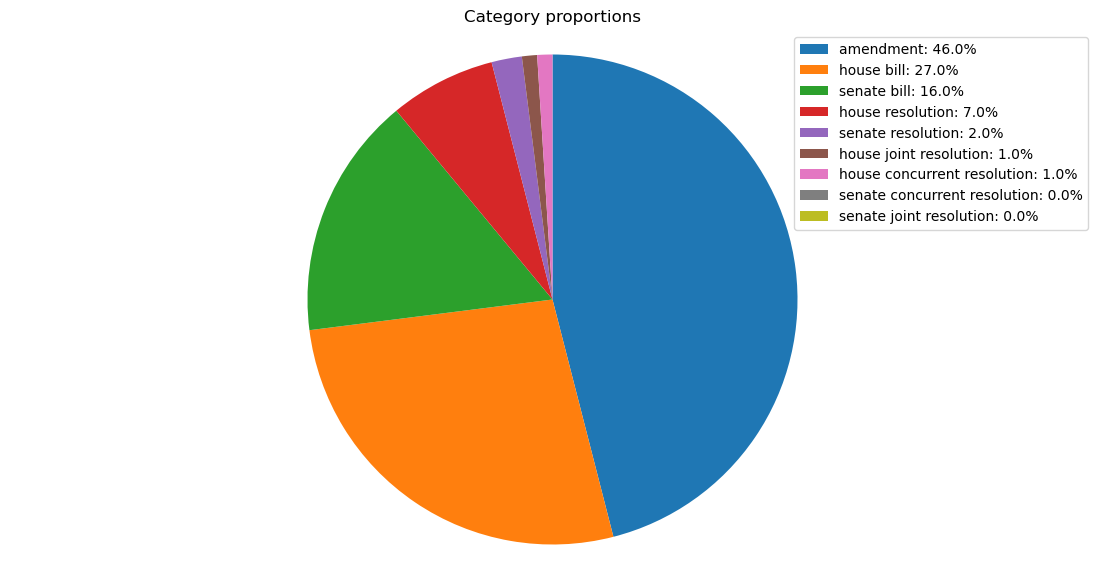

In [5]:
# Calculate proportion of the rows belong to different categories
cat_prop = bills_actions["category"].value_counts(normalize=True).round(2)
# create a new column: category proportions
bills_actions["cat_p"] = bills_actions["category"].map(cat_prop)

# Draw pie chart for categories
plt.figure(figsize=(14, 7))
plt.pie(cat_prop.values,
        labels=None,
        autopct=None,
        startangle=90,
        counterclock=False
        )
plt.title("Category proportions")
legend_labels = [f"{label}: {value:.1%}" for label, value in cat_prop.items()]
plt.legend(legend_labels, loc="upper right")
plt.axis("equal")
plt.show()

<font size = "4">

**Interpretation:** Amendments are the most common bill type, accounting for nearly half of all bills. This suggests many legislative bills are modifying existing legislation.

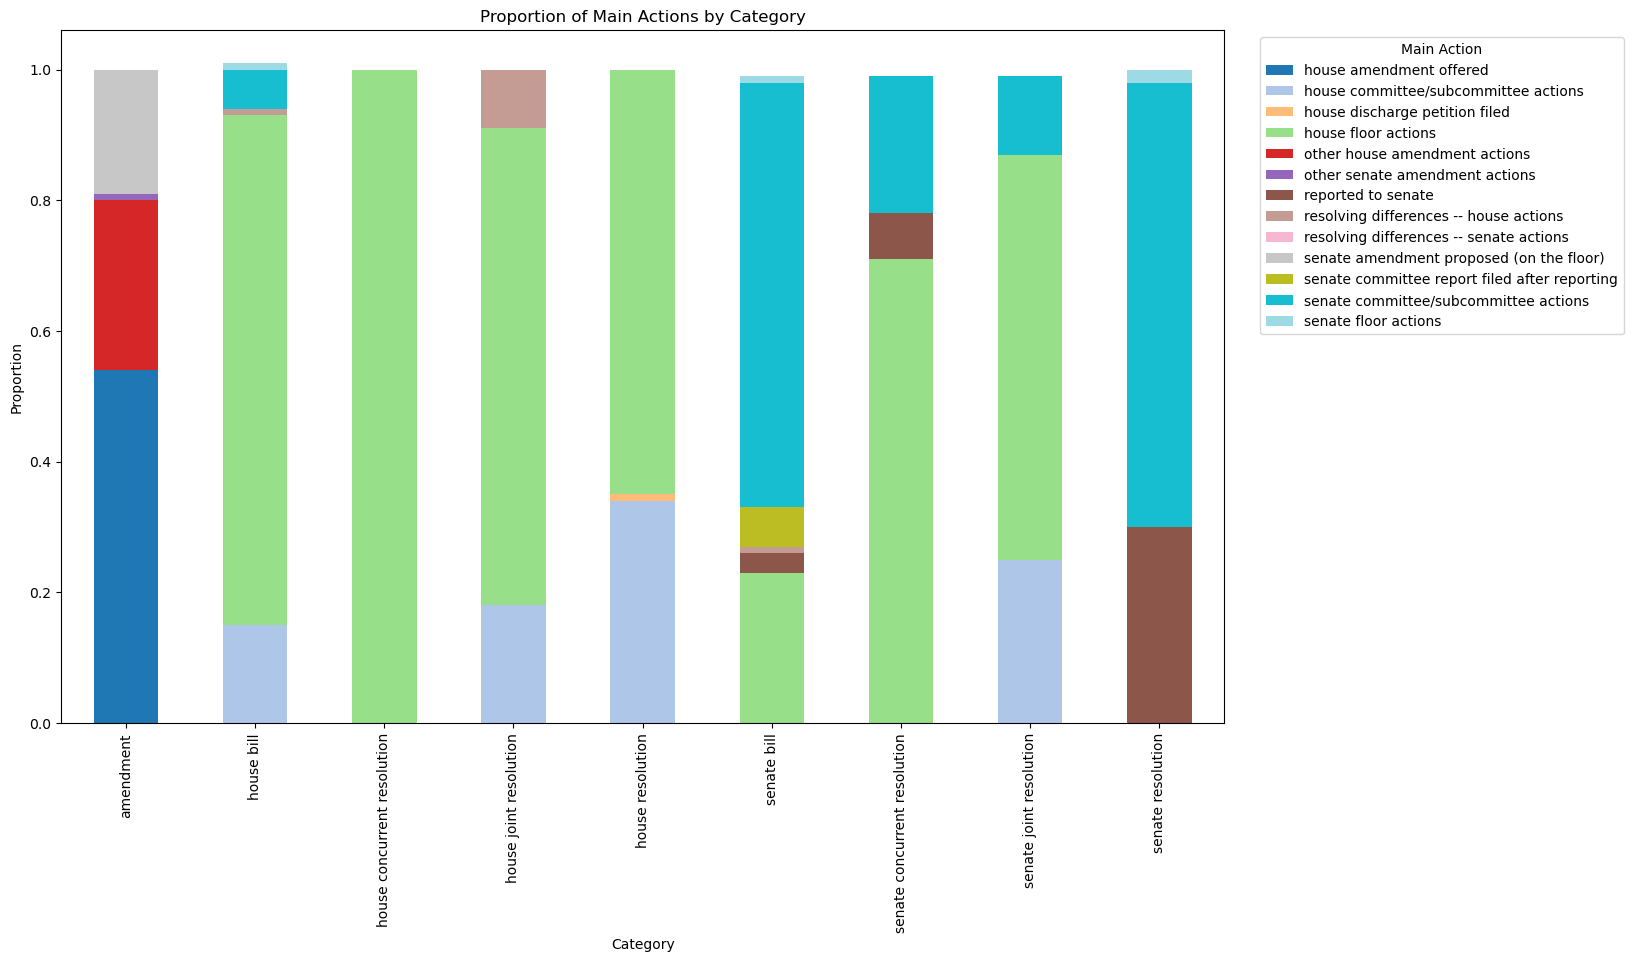

In [6]:
# In each category,
# calculate the proportion of different "main_action"
categaction = pd.crosstab(
    bills_actions["category"],
    bills_actions["main_action"],
    normalize="index").round(2)

# Draw stacked plot diagram
categaction.plot(kind='bar', stacked=True, figsize=(15, 9), colormap='tab20')
plt.title("Proportion of Main Actions by Category")
plt.xlabel("Category")
plt.ylabel("Proportion")
plt.legend(title="Main Action", bbox_to_anchor=(1.35, 1), loc='upper right')
plt.show()

<font size = "4">

**Interpretation:** This stacked bar chart shows composition of main_action types within each bill category. And I found that House and Senate have distinctly different legislative procedures. For example, in termS of concurrent resolution, House concurrent resolution has highly homogeneous action type, just House floor actions. But Senator concurrent resolutions consist of committee actions, reported to Senate and House floor actions, which suggests higher procedural complexity.

# <span style="color:darkblue"> **Step3a: Subset House Floor Actions** </span>

<font size = "3">

I first subset the data using the query() function to include only Senate bills and further restricted the selection to House floor actions.

To calculate the proportions of suspension actions and amendment actions, I applied regular expressions to identify rows in which the action text contains the keywords “suspend” and “amend.” I then computed their proportions by dividing the number of matched rows by the total number of bills in the subset using the len() method.

In [7]:
# Count house floor actions in senate bills
senate_bills = bills_actions.query('category == "senate bill"')
house = senate_bills.query('main_action == "house floor actions"')
len(house)

116

<font size = "4">

**Interpretation:**
There are 116 bills that satified conditions of Senate bills whose main action is House floor actions.

In [8]:
# Calculate proportion of suspended actions
act_suspend = house[house["action"].str.contains("suspend")]
suspend_prop = len(act_suspend)/len(house)

# Calculate proportion of amended actions
act_amend = house[house["action"].str.contains('amend')]
amend_prop = len(act_amend)/len(house)

print(suspend_prop)
print(amend_prop)

0.6896551724137931
0.15517241379310345


<font size = "4">

**Interpretation:** 
68.97% of Senate bills were suspended in house floor actions, and 15.52% were suspended as amended.

# <span style="color:darkblue"> **Step3b: Visualizing Partcipation** </span>

<font size = "4">

To identify which who are proposing these actions, I used regular expressions to extract Senators' names from the action text. Using the previously constructed bill_id, I combined each identifier with the corresponding extracted names. 

I then created a new dataset by grouping the records by person and counting the number of distinct Senate bills in which each member was mentioned.

Finally, I plotted the distribution of the total number of bills per person.

In [9]:
#Extract name from house floor actions data
name_action = house["action"].str.findall(r"(?:Mr\.|Mrs\.|Ms\.)\s[A-Z][a-zA-Z-]+(?:\s[A-Z][a-zA-Z-]+)*")

# Create a new dataset
# Combining bill id and perrson names
# The extracted names are lists now, so I deal it with explode()
person_data = (
    pd.DataFrame({"bill_id": bill_id, "person": name_action})
      .explode("person")
      .dropna()
      .drop_duplicates(subset=["bill_id", "person"])
)
person_data


,bill_id,person
559,s1436,Ms. Lofgren
560,s1693,Mr. Evans
562,s1749,Mr. Clay
563,s2047,Ms. DeGette
564,s2249,Mr. Larsen
...,...,...
790,s906,Mr. Huffman
792,s945,Mr. Clay
794,s979,Ms. Norton
796,s982,Ms. Scanlon


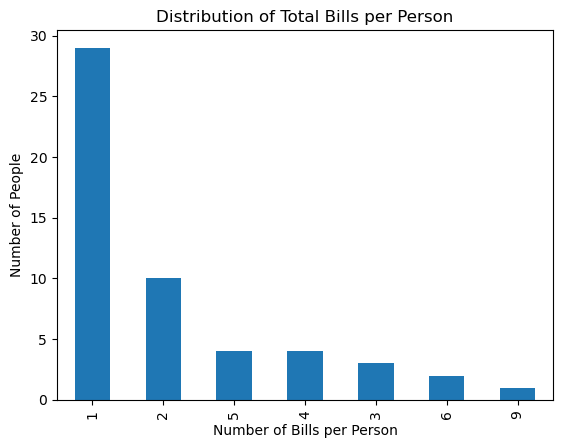

In [10]:
# Counting how many bills mention the same person
per_person = (person_data.groupby("person")["bill_id"]
              .nunique()
              .reset_index(name="bills_num")
              .sort_values("bills_num", ascending=False))

# Draw plot
per_person["bills_num"].value_counts().plot(kind="bar")
plt.xlabel("Number of Bills per Person")
plt.ylabel("Number of People")
plt.title("Distribution of Total Bills per Person")
plt.show()


<font size = '4'>

**Interpretation of Distribution Graph:** The distribution of the total number of bills per person shows a left skewed pattern, which means the majority of individuals were mentioned in a few number of bills. Only a small number of members were mentioned in multiple bills. This indicates that House floor actions on Senate bills tend to involve a small group of highly active members, whereas most members appear infrequently in these actions.

# <span style="color:darkblue"> **Step4: Visualizing Partcipation** </span>

<font size = "4">

I first subset the dataset to include only actions classified as “senate amendment proposed (on the floor).” I then applied regular expressions to extract the names of Senators mentioned in each action text. Specifically, I searched for strings beginning with “Senator” followed by one or capitalized names, 

` I write "[A-Z][a-zA-Z-]" in case people have more than one capitalized charracters in their surnnames 

` I wrote "(?:\s[A-Z][a-zA-Z-]+)*" allowing for middle names or more than one surnames .

I then constructed a structured dataset that recorded the number of Senators mentioned per bill, as well as the first and second Senators listed for each action. I also check the number of coauthor each senator1 have using group by.

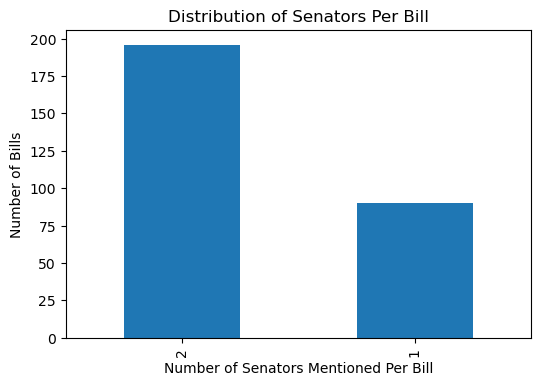

In [11]:
# Subset actions: "senate amendment proposed(on the floor)”
amend_floor = bills_actions.query('main_action == "senate amendment proposed (on the floor)"').copy()

# Create a dataset names of senators per bill 
# Extract senators' names
amend_floor["senators_perbill"] = amend_floor["action"].str.findall(r"\bSenator\s[A-Z][a-zA-Z-]+(?:\s[A-Z][a-zA-Z-]+)*")

senators = pd.DataFrame({
    "bill_id": amend_floor["bill_id"],
    "senators_num": amend_floor["senators_perbill"].str.len(),
    "senator1": amend_floor["senators_perbill"].str[0],
    "senator2": amend_floor["senators_perbill"].str[1],
})

# Draw graph the distribution of senator number
senators["senators_num"].value_counts().plot(kind="bar", figsize=(6,4))
plt.xlabel("Number of Senators Mentioned Per Bill")
plt.ylabel("Number of Bills")
plt.title("Distribution of Senators Per Bill")
plt.show()



In [12]:
# Group by senator 1, count coauthors for each senator 1
coauthors = (senators
             .groupby("senator1")["senator2"].nunique()
             .reset_index(name="coauthors_num")
             .sort_values("coauthors_num", ascending=False)
)
coauthors

,senator1,coauthors_num
14,Senator McConnell,57
23,Senator Reed,25
2,Senator Cornyn,9
3,Senator Cramer,7
18,Senator Murkowski,6
0,Senator Braun,5
17,Senator Moran,4
35,Senator Thune,3
13,Senator Lee,3
26,Senator Sasse,2


# <span style="color:darkblue"> **Brief Insights** </span>

<font size = "4">

1. Many bills appear repeatedly in the dataset, reflecting multiple rounds of amendments and actions. This indicates that this set of bills received high attention and underwent extensive deliberation and revision.

2. There are clear procedural differences between actions taken on the floor and those involving Senators. And they also have very different procedures at different stages.

3. Within House floor actions on Senate bills, suspension motions are common, but the proportion of amendments is relatively low. This suggests that the House may often chooses to expedite the passage of Senate bills through suspension of the rules, rather than engaging in substantial modification.

4. The collaboration patterns reveal that a few Senators play particularly central and dominant roles in amendment activity. Certain individuals, such as **Senator McConnell** and **Senator Reed**, have extensive networks of co-sponsors or collaborators, indicating leadership or coordination roles in the legislative process.